In [1]:
!rm -rf diploma_centpy_parallelization_py
# Флаг -b указывает конкретную ветку
!git clone -b feature/jax-centpy https://github.com/filkinc/diploma_centpy_parallelization_py.git
%cd diploma_centpy_parallelization_py
%cd /content/diploma_centpy_parallelization_py/jax_centpy

# Установка зависимостей
!pip install centpy pandas matplotlib seaborn scienceplots

Cloning into 'diploma_centpy_parallelization_py'...
remote: Enumerating objects: 561, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 561 (delta 37), reused 80 (delta 28), pack-reused 418 (from 1)
Receiving objects: 100% (561/561), 47.26 MiB | 16.13 MiB/s, done.
Resolving deltas: 100% (246/246), done.
/content/diploma_centpy_parallelization_py
/content/diploma_centpy_parallelization_py/jax_centpy


In [2]:
import os
import time
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np
from google.colab import files

from core import Pars2d, Equation2d
from solver import Solver2d, FastSolver2d, FastSolverWithAllLayersWithoutExtends2d
from boundaries import periodic_bc_2d, neumann_bc_2d, dirichlet_riemann_bc_2d, wall_bc_2d
from equations import make_euler_riemann_2d, make_euler_isentropic_vortex_2d
from schemes import compute_rhs_sd2_2d
from limiters import monotonized_central, minmod
from richardson import self_convergence_analysis

In [3]:
def make_euler_shock_two_bubbles_2d(gamma: float = 1.4, alpha: float = 0.1):
    """
    Модифицированная 2D задача Эйлера: взаимодействие ударной волны
    с двумя пузырями низкой плотности, расположенными по диагонали.

    Пузырь 1 (круглый):  центр (0.45, 0.65), радиус 0.08
    Пузырь 2 (квадрат):  x in [0.25, 0.41], y in [0.20, 0.44]

    Ударная волна справа (x >= 0.8): параметры Маха 2.0
    Фон: (rho, u, v, p) = (1.0, 0.0, 0.0, 1.0)
    Оба пузыря: rho = alpha * rho0, p = p0 (изобарно)

    Физический смысл: сравнение рефракции на скруглённой (круг)
    и острой (квадрат) геометрии зоны энерговложения в одном расчёте.
    """

    def compute_pressure(q):
        rho = q[..., 0]
        u   = q[..., 1] / jnp.maximum(rho, 1e-10)
        v   = q[..., 2] / jnp.maximum(rho, 1e-10)
        return (gamma - 1.0) * (q[..., 3] - 0.5 * rho * (u**2 + v**2))

    def flux_x(q):
        rho  = q[..., 0]
        rhou = q[..., 1]
        rhov = q[..., 2]
        E    = q[..., 3]
        u    = rhou / jnp.maximum(rho, 1e-10)
        p    = compute_pressure(q)
        return jnp.stack([
            rhou,
            rhou * u + p,
            rhou * (rhov / jnp.maximum(rho, 1e-10)),
            (E + p) * u
        ], axis=-1)

    def flux_y(q):
        rho  = q[..., 0]
        rhou = q[..., 1]
        rhov = q[..., 2]
        E    = q[..., 3]
        v    = rhov / jnp.maximum(rho, 1e-10)
        p    = compute_pressure(q)
        return jnp.stack([
            rhov,
            rhov * (rhou / jnp.maximum(rho, 1e-10)),
            rhov * v + p,
            (E + p) * v
        ], axis=-1)

    def spectral_radius_x(q):
        rho   = q[..., 0]
        rhou  = q[..., 1]
        rho_s = jnp.maximum(rho, 1e-10)
        u     = rhou / rho_s
        p     = jnp.maximum(compute_pressure(q), 1e-10)
        return jnp.abs(u) + jnp.sqrt(gamma * p / rho_s)

    def spectral_radius_y(q):
        rho   = q[..., 0]
        rhov  = q[..., 2]
        rho_s = jnp.maximum(rho, 1e-10)
        v     = rhov / rho_s
        p     = jnp.maximum(compute_pressure(q), 1e-10)
        return jnp.abs(v) + jnp.sqrt(gamma * p / rho_s)

    def initial_two_bubbles(x, y):
        # --- геометрия пузырей ---
        # Пузырь 1: круг, верхний правый
        cx1, cy1, r1 = 0.45, 0.65, 0.08
        circle_mask = (x - cx1)**2 + (y - cy1)**2 <= r1**2

        # Пузырь 2: квадрат, нижний левый
        x2a, x2b = 0.25, 0.41
        y2a, y2b = 0.20, 0.44
        square_mask = (x >= x2a) & (x <= x2b) & (y >= y2a) & (y <= y2b)

        # Ударная волна
        shock_mask = x >= 0.8

        # Параметры ударной волны (Маха 2.0, из Ренкина-Гюгонио)
        rho_shock, u_shock, p_shock = 2.667, -1.479, 4.5

        # Фон
        rho0, p0 = 1.0, 1.0

        # Плотность в пузырях
        rho_bubble = alpha * rho0   # 0.1

        # Сборка: приоритет — ударная волна > пузыри > фон
        bubble_mask = circle_mask | square_mask

        rho = jnp.where(shock_mask, rho_shock,
              jnp.where(bubble_mask, rho_bubble, rho0))

        u   = jnp.where(shock_mask, u_shock, 0.0)
        v   = jnp.zeros_like(x)
        p   = jnp.where(shock_mask, p_shock, p0)

        E = p / (gamma - 1.0) + 0.5 * rho * (u**2 + v**2)
        return jnp.stack([rho, rho * u, rho * v, E], axis=-1)

    return Equation2d(
        flux_x=flux_x,
        flux_y=flux_y,
        spectral_radius_x=spectral_radius_x,
        spectral_radius_y=spectral_radius_y,
        initial_data=initial_two_bubbles,
        boundary_handler=wall_bc_2d,
        name="Euler 2D Shock-Two-Bubbles"
    )

In [ ]:
# Модифицированная задача с энерговложением квадрат

def make_euler_shock_stratified_2d(gamma: float = 1.4, alpha: float = 0.1):
    """
    Модифицированная 2D задача Эйлера: взаимодействие ударной волны
    со стратифицированной по плотности прямоугольной зоной энерговложения.

    Зона энерговложения: x in [0.3, 0.5], y in [0.2, 0.8] — квадрат.
    Внутри зоны плотность линейно растёт от alpha*rho0 (y=y1) до rho0 (y=y2).
    Давление везде равно p0 (изобарная постановка).

    Физический смысл: тепловой след с вертикальным градиентом температуры —
    нижняя часть горячее (меньше плотность), верхняя холоднее.
    """

    # --- физические потоки и спектральные радиусы ---
    def compute_pressure(q):
        rho = q[..., 0]
        u   = q[..., 1] / jnp.maximum(rho, 1e-10)
        v   = q[..., 2] / jnp.maximum(rho, 1e-10)
        return (gamma - 1.0) * (q[..., 3] - 0.5 * rho * (u**2 + v**2))

    def flux_x(q):
        rho  = q[..., 0]
        rhou = q[..., 1]
        rhov = q[..., 2]
        E    = q[..., 3]
        u    = rhou / jnp.maximum(rho, 1e-10)
        p    = compute_pressure(q)
        return jnp.stack([
            rhou,
            rhou * u + p,
            rhou * (rhov / jnp.maximum(rho, 1e-10)),
            (E + p) * u
        ], axis=-1)

    def flux_y(q):
        rho  = q[..., 0]
        rhou = q[..., 1]
        rhov = q[..., 2]
        E    = q[..., 3]
        v    = rhov / jnp.maximum(rho, 1e-10)
        p    = compute_pressure(q)
        return jnp.stack([
            rhov,
            rhov * (rhou / jnp.maximum(rho, 1e-10)),
            rhov * v + p,
            (E + p) * v
        ], axis=-1)

    def spectral_radius_x(q):
        rho  = q[..., 0]
        rhou = q[..., 1]
        rho_s = jnp.maximum(rho, 1e-10)
        u     = rhou / rho_s
        p     = jnp.maximum(compute_pressure(q), 1e-10)
        return jnp.abs(u) + jnp.sqrt(gamma * p / rho_s)

    def spectral_radius_y(q):
        rho  = q[..., 0]
        rhov = q[..., 2]
        rho_s = jnp.maximum(rho, 1e-10)
        v     = rhov / rho_s
        p     = jnp.maximum(compute_pressure(q), 1e-10)
        return jnp.abs(v) + jnp.sqrt(gamma * p / rho_s)

    # --- начальные условия ---
    def initial_stratified(x, y):
        # Границы зоны энерговложения
        x1, x2 = 0.3, 0.5
        y1, y2 = 0.2, 0.8   # квадрат по Y

        # Маски
        shock_mask  = x >= 0.8
        zone_mask   = (x >= x1) & (x <= x2) & (y >= y1) & (y <= y2)

        # Параметры ударной волны (Маха 2.0)
        rho_shock, u_shock, p_shock = 2.667, -1.479, 4.5

        # Фоновые параметры
        rho0, p0 = 1.0, 1.0

        # Плотность внутри зоны: линейно растёт от alpha*rho0 (y=y1) до rho0 (y=y2)
        # t = 0 при y=y1, t = 1 при y=y2
        t = (y - y1) / (y2 - y1)                         # [0, 1]
        t = jnp.clip(t, 0.0, 1.0)
        rho_zone = rho0 * (alpha + (1.0 - alpha) * t)    # [alpha, 1] * rho0

        # Сборка полей: приоритет — ударная волна > зона > фон
        rho = jnp.where(shock_mask, rho_shock,
              jnp.where(zone_mask,  rho_zone, rho0))

        u   = jnp.where(shock_mask, u_shock, 0.0)
        v   = jnp.zeros_like(x)
        p   = jnp.where(shock_mask, p_shock, p0)  # изобарно в зоне

        E = p / (gamma - 1.0) + 0.5 * rho * (u**2 + v**2)
        return jnp.stack([rho, rho * u, rho * v, E], axis=-1)

    return Equation2d(
        flux_x=flux_x,
        flux_y=flux_y,
        spectral_radius_x=spectral_radius_x,
        spectral_radius_y=spectral_radius_y,
        initial_data=initial_stratified,
        boundary_handler=wall_bc_2d,
        name="Euler 2D Shock-Stratified-Zone"
    )

In [ ]:
# "Модифицированная" постановка задачи с кругом в центре (ее на называю классической)
def make_euler_shock_bubble_2d(gamma: float = 1.4):
    """
    2D Euler: Взаимодействие ударной волны с пузырём низкой плотности.

    Начальные условия:
    - Ударная волна справа (x ≥ 0.8): (ρ, u, v, p) = (2.667, -1.479, 0.0, 4.5)
    - Пузырь в центре (x-0.4)² + (y-0.5)² ≤ 0.1²: (ρ, u, v, p) = (0.1, 0.0, 0.0, 1.0)
    - Фон: (ρ, u, v, p) = (1.0, 0.0, 0.0, 1.0)

    Граничные условия: wall (непротекание)
    """
    def compute_pressure(q):
        rho = q[..., 0]
        u = q[..., 1] / rho
        v = q[..., 2] / rho
        return (gamma - 1.0) * (q[..., 3] - 0.5 * rho * (u ** 2 + v ** 2))

    def flux_x(q):
        rho = q[..., 0]
        rhou = q[..., 1]
        rhov = q[..., 2]
        E = q[..., 3]

        rho_safe = jnp.maximum(rho, 1e-10)
        u = rhou / rho_safe
        p = compute_pressure(q)

        return jnp.stack([
            rhou,
            rhou * u + p,
            rhou * (rhov / rho_safe),
            (E + p) * u
        ], axis=-1)

    def flux_y(q):
        rho = q[..., 0]
        rhou = q[..., 1]
        rhov = q[..., 2]
        E = q[..., 3]

        rho_safe = jnp.maximum(rho, 1e-10)
        v = rhov / rho_safe
        p = compute_pressure(q)

        return jnp.stack([
            rhov,
            rhov * (rhou / rho_safe),
            rhov * v + p,
            (E + p) * v
        ], axis=-1)

    def spectral_radius_x(q):
        rho = q[..., 0]
        rhou = q[..., 1]

        rho_safe = jnp.maximum(rho, 1e-10)
        u = rhou / rho_safe
        p = compute_pressure(q)
        p_safe = jnp.maximum(p, 1e-10)

        c = jnp.sqrt(gamma * p_safe / rho_safe)
        return jnp.abs(u) + c

    def spectral_radius_y(q):
        rho = q[..., 0]
        rhov = q[..., 2]

        rho_safe = jnp.maximum(rho, 1e-10)
        v = rhov / rho_safe
        p = compute_pressure(q)
        p_safe = jnp.maximum(p, 1e-10)

        c = jnp.sqrt(gamma * p_safe / rho_safe)
        return jnp.abs(v) + c

    def initial_shock_bubble(x, y):
        """
        Начальные условия с тремя областями:
        1. Ударная волна справа: x ≥ 0.8
        2. Пузырь в центре: (x-0.4)² + (y-0.5)² ≤ 0.1²
        3. Фон: всё остальное
        """
        # Условие для ударной волны
        shock_mask = x >= 0.8

        # Условие для пузыря
        bubble_mask = (x - 0.4)**2 + (y - 0.5)**2 <= 0.1**2

        # Ударная волна (приоритет выше пузыря)
        rho_shock = 2.667
        u_shock = -1.479
        v_shock = 0.0
        p_shock = 4.5

        # Пузырь
        rho_bubble = 0.1
        u_bubble = 0.0
        v_bubble = 0.0
        p_bubble = 1.0

        # Фон
        rho_bg = 1.0
        u_bg = 0.0
        v_bg = 0.0
        p_bg = 1.0

        # Применяем условия последовательно: сначала фон, потом пузырь, потом ударная волна
        rho = jnp.where(shock_mask, rho_shock,
                       jnp.where(bubble_mask, rho_bubble, rho_bg))

        u = jnp.where(shock_mask, u_shock,
                     jnp.where(bubble_mask, u_bubble, u_bg))

        v = jnp.where(shock_mask, v_shock,
                     jnp.where(bubble_mask, v_bubble, v_bg))

        p = jnp.where(shock_mask, p_shock,
                     jnp.where(bubble_mask, p_bubble, p_bg))

        # Вычисляем полную энергию
        E = p / (gamma - 1.0) + 0.5 * rho * (u**2 + v**2)

        return jnp.stack([rho, rho * u, rho * v, E], axis=-1)

    return Equation2d(
        flux_x=flux_x,
        flux_y=flux_y,
        spectral_radius_x=spectral_radius_x,
        spectral_radius_y=spectral_radius_y,
        initial_data=initial_shock_bubble,
        boundary_handler=wall_bc_2d,
        name="Euler 2D Shock-Bubble"
    )

In [ ]:
# Уравнение для проверки 2 порядка точности

def make_euler_isentropic_vortex_2d_colab(gamma: float = 1.4):
    """
    Гладкое точное решение: Изоэнтропийный вихрь.
    Идеально для проверки сходимости 2D Эйлера. Периодические граничные условия.
    Домен: x, y в [0, 10]. Центр вихря (5, 5). Скорость потока (1, 1).
    """

    def _compute_pressure(q):
        rho, u, v, E = q[..., 0], q[..., 1] / q[..., 0], q[..., 2] / q[..., 0], q[..., 3]
        return (gamma - 1.0) * (E - 0.5 * rho * (u ** 2 + v ** 2))

    def flux_x(q):
        rho, rhou, rhov, E = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
        u = rhou / rho;
        p = _compute_pressure(q)
        return jnp.stack([rhou, rhou * u + p, rhou * (rhov / rho), u * (E + p)], axis=-1)

    def flux_y(q):
        rho, rhou, rhov, E = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
        v = rhov / rho;
        p = _compute_pressure(q)
        return jnp.stack([rhov, rhov * (rhou / rho), rhov * v + p, v * (E + p)], axis=-1)

    def spectral_radius_x(q):
        rho, u, p = q[..., 0], q[..., 1] / q[..., 0], _compute_pressure(q)
        return jnp.abs(u) + jnp.sqrt(gamma * p / rho)

    def spectral_radius_y(q):
        rho, v, p = q[..., 0], q[..., 2] / q[..., 0], _compute_pressure(q)
        return jnp.abs(v) + jnp.sqrt(gamma * p / rho)

    # Функция генерирует точное решение для любого момента t
    def exact_solution(x, y, t=0.0):
        beta = 5.0
        # Смещение вихря с учетом скорости потока u=1, v=1 и периодичности
        dx = (x - 5.0 - t) % 10.0
        dy = (y - 5.0 - t) % 10.0
        dx = jnp.where(dx > 5.0, dx - 10.0, dx)
        dy = jnp.where(dy > 5.0, dy - 10.0, dy)

        r2 = dx ** 2 + dy ** 2
        du = - (beta / (2 * jnp.pi)) * jnp.exp(0.5 * (1.0 - r2)) * dy
        dv = (beta / (2 * jnp.pi)) * jnp.exp(0.5 * (1.0 - r2)) * dx

        u, v = 1.0 + du, 1.0 + dv
        T = 1.0 - ((gamma - 1.0) * beta ** 2 / (8 * gamma * jnp.pi ** 2)) * jnp.exp(1.0 - r2)
        rho = T ** (1.0 / (gamma - 1.0))
        p = rho ** gamma
        E = p / (gamma - 1.0) + 0.5 * rho * (u ** 2 + v ** 2)
        return jnp.stack([rho, rho * u, rho * v, E], axis=-1)

    return Equation2d(
        flux_x=flux_x, flux_y=flux_y,
        spectral_radius_x=spectral_radius_x, spectral_radius_y=spectral_radius_y,
        initial_data=lambda x, y: exact_solution(x, y, 0.0),
        boundary_handler=periodic_bc_2d,
        name="Euler 2D (Isentropic Vortex)"
    )

In [ ]:
# Основная функция проверки скорости работы схемы
# Здесь проверяется старый Solver для sd2
def run_gpu_benchmark():
    print(f"JAX Device(s): {jax.devices()}")
    J = 200

    # Для make_euler_riemann_2d and make_euler_shock_bubble_2d
    pars = Pars2d(
        x_init=0.0, x_final=1.0, y_init=0.0, y_final=1.0,
        t_final=0.4, dt_out=0.005, Jx=J, Jy=J, cfl=0.475, scheme="аd2"
    )


    # Для make_euler_isentropic_vortex_2d_colab
    # pars = Pars2d(
    #     x_init=0.0, x_final=10.0, y_init=0.0, y_final=10.0,
    #     t_final=5.0, dt_out=0.005, Jx=J, Jy=J, cfl=0.475, scheme="sd2"
    # )

    eqn = make_euler_shock_bubble_2d()
    solver = FastSolver2d(pars, eqn, scheme_name="sd2", limiter_name="minmod")
    solverForPlot = Solver2d(pars, eqn, scheme_name="sd2")

    # Для схем SD2, SD3
    print("--- Прогрев JAX (Компиляция XLA) ---")
    # Прогреваем ТОЛЬКО первый шаг решателя (именно он содержит всю тяжелую математику)
    x_1d = jnp.linspace(pars.x_init + pars.dx / 2, pars.x_final - pars.dx / 2, pars.Jx)
    y_1d = jnp.linspace(pars.y_init + pars.dy / 2, pars.y_final - pars.dy / 2, pars.Jy)
    X, Y = jnp.meshgrid(x_1d, y_1d, indexing='ij')
    test_u = eqn.initial_data(X, Y)
    _ = solver.update_step_jit(0.0, test_u, 0.001).block_until_ready()
    print("Прогрев завершен.\n")

    print(f"--- Запуск JAX GPU Бенчмарка (Euler 2D Riemann, {J}x{J}) ---")
    t0 = time.time()
    results = solver.solve()
    results['u'][-1].block_until_ready()
    t1 = time.time()

    print(f"\n[GPU JAX] Чистое время выполнения: {t1 - t0:.4f} секунд")

    resultsForPlot = solverForPlot.solve()

    return resultsForPlot, pars

if __name__ == "__main__":
    jax.config.update("jax_enable_x64", True)
    run_gpu_benchmark()

JAX Device(s): [CudaDevice(id=0)]
--- Прогрев JAX (Компиляция XLA) ---
Прогрев завершен.

--- Запуск JAX GPU Бенчмарка (Euler 2D Riemann, 200x200) ---

[GPU JAX] Чистое время выполнения: 4.5195 секунд
Starting 2D simulation: Euler 2D Shock-Bubble
Grid: 200x200, Scheme: sd2/minmod


In [ ]:
# Здесь проверяю fd2
def run_gpu_benchmark():
    print(f"JAX Device(s): {jax.devices()}")
    J = 200

    # Для make_euler_riemann_2d and make_euler_shock_bubble_2d
    pars = Pars2d(
        x_init=0.0, x_final=1.0, y_init=0.0, y_final=1.0,
        t_final=0.4, dt_out=0.005, Jx=J, Jy=J, cfl=0.475, scheme="fd2"
    )


    # Для make_euler_isentropic_vortex_2d_colab
    # pars = Pars2d(
    #     x_init=0.0, x_final=10.0, y_init=0.0, y_final=10.0,
    #     t_final=5.0, dt_out=0.005, Jx=J, Jy=J, cfl=0.475, scheme="sd2"
    # )

    eqn = make_euler_shock_bubble_2d()
    solver = FastSolver2d(pars, eqn, scheme_name="fd2", limiter_name="minmod")
    solverForPlot = Solver2d(pars, eqn, scheme_name="fd2")

    print(f"--- Запуск JAX GPU Бенчмарка (Euler 2D Riemann, {J}x{J}) ---")
    t0 = time.time()
    results = solver.solve()
    results['u'][-1].block_until_ready()
    t1 = time.time()

    print(f"\n[GPU JAX] Чистое время выполнения: {t1 - t0:.4f} секунд")

    resultsForPlot = solverForPlot.solve()

    return resultsForPlot, pars

if __name__ == "__main__":
    jax.config.update("jax_enable_x64", True)
    soln, pars = run_gpu_benchmark()

JAX Device(s): [CudaDevice(id=0)]
--- Запуск JAX GPU Бенчмарка (Euler 2D Riemann, 200x200) ---

[GPU JAX] Чистое время выполнения: 8.0131 секунд
Starting 2D simulation: Euler 2D Shock-Bubble
Grid: 200x200, Scheme: fd2/minmod


In [4]:
# Здесь я проверял FastSolverWithAllLayersWithoutExtends2d
def run_gpu_benchmark():
    print(f"JAX Device(s): {jax.devices()}")
    J = 200

    pars = Pars2d(
        x_init=0.0, x_final=1.0, y_init=0.0, y_final=1.0,
        t_final=0.4, dt_out=0.005, Jx=J, Jy=J, cfl=0.475, scheme="sd2"
    )

    eqn = make_euler_shock_two_bubbles_2d()
    solver = FastSolverWithAllLayersWithoutExtends2d(pars, eqn, scheme_name="sd2", limiter_name="minmod")

    print("--- Прогрев JAX (Компиляция XLA) ---")
    # Простой прогрев через двойной вызов solve()
    warmup = solver.solve()
    print("Прогрев завершен.\n")

    print(f"--- Запуск JAX GPU Бенчмарка (Euler 2D Shock-Bubble, {J}x{J}) ---")
    t0 = time.time()
    results = solver.solve()
    results['u'][-1].block_until_ready()
    t1 = time.time()

    print(f"\n[GPU JAX] Чистое время выполнения: {t1 - t0:.4f} секунд")
    print(f"Сохранено snapshots: {len(results['t'])}")
    print(f"Всего временных шагов: {results['steps']}")

    return results, pars


if __name__ == "__main__":
    jax.config.update("jax_enable_x64", True)
    soln, pars = run_gpu_benchmark()

JAX Device(s): [CudaDevice(id=0)]
--- Прогрев JAX (Компиляция XLA) ---
Прогрев завершен.

--- Запуск JAX GPU Бенчмарка (Euler 2D Shock-Bubble, 200x200) ---

[GPU JAX] Чистое время выполнения: 1.2191 секунд
Сохранено snapshots: 81
Всего временных шагов: 1399


In [ ]:
# Приводим к единому стандарту: X, Y, t, u
# Берем данные из вашего словаря soln
np.savez('gpu_data.npz',
         X=np.array(soln['X']),
         Y=np.array(soln['Y']),
         u=np.array(soln['u'])) # Выгружаем весь массив u

# Скачиваем
files.download('gpu_data.npz')

NameError: name 'soln' is not defined

In [ ]:
u_data = soln['u']
X_grid = soln['X']
Y_grid = soln['Y']

# Инициализация фигуры и осей, берем границы из объекта pars
fig, ax = plt.subplots()
ax.set_xlim(pars.x_init, pars.x_final)
ax.set_ylim(pars.y_init, pars.y_final)

# Для первого кадра (плотность, так как индекс [..., 0] соответствует плотности в уравнениях Эйлера)
data_init = u_data[0, ..., 0]

# 1. Создаем фоновую тепловую карту с помощью imshow
im = ax.imshow(
    data_init.T, # Транспонируем, так как imshow ожидает порядок (y, x), а у вас индексация 'ij'
    extent=[pars.x_init, pars.x_final, pars.y_init, pars.y_final],
    origin='lower',
    cmap='coolwarm',            # Золотой стандарт для волновых процессов; Или 'magma', 'viridis', 'turbo'
    interpolation='bicubic',
    aspect='auto'
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Плотность (u[..., 0])')

# 2. Отрисовываем начальные контуры поверх тепловой карты
ax.contour(
    X_grid, Y_grid, data_init,
    levels=20,
    colors='black',
    alpha=0.5,
    linewidths=0.5
)

# Функция для сохранения картинки
def save_frame(frame_idx, filename):
    """Сохраняет указанный кадр как изображение"""
    fig_temp, ax_temp = plt.subplots()
    ax_temp.set_xlim(pars.x_init, pars.x_final)
    ax_temp.set_ylim(pars.y_init, pars.y_final)

    data = u_data[frame_idx, ..., 0]

    # Тепловая карта
    im_temp = ax_temp.imshow(
        data.T,
        extent=[pars.x_init, pars.x_final, pars.y_init, pars.y_final],
        origin='lower',
        cmap='coolwarm',
        interpolation='bicubic',
        aspect='auto'
    )

    cbar_temp = fig_temp.colorbar(im_temp, ax=ax_temp)
    cbar_temp.set_label('Плотность (u[..., 0])')

    # Контуры
    ax_temp.contour(
        X_grid, Y_grid, data,
        levels=20,
        colors='black',
        alpha=0.5,
        linewidths=0.5
    )

    # Сохраняем физический файл на диск перед скачиванием
    fig_temp.savefig(filename, bbox_inches='tight', dpi=150)

    # Закрываем фигуру, чтобы она не выводилась на экран в ячейке
    plt.close(fig_temp)

    files.download(filename);

# Сохраняем первый кадр
save_frame(0, 'first_frame.png');
print("Сохранен первый кадр: first_frame.png")

# Сохраняем последний кадр
last_frame_idx = u_data.shape[0] - 1
save_frame(last_frame_idx, 'last_frame.png');
print(f"Сохранен последний кадр (индекс {last_frame_idx}): last_frame.png")

# Функция обновления для каждого кадра анимации
def animate(i):
    # Получаем данные текущего шага
    data = u_data[i, ..., 0]

    # Обновляем данные на тепловой карте
    im.set_data(data.T)

    # Динамически обновляем границы цветовой шкалы (опционально)
    im.set_clim(vmin=data.min(), vmax=data.max())

    # Удаляем старые линии контуров из коллекции осей
    for c in ax.collections:
        c.remove()

    # Рисуем новые контурные линии
    ax.contour(
        X_grid, Y_grid, data,
        levels=20,
        colors='black',
        alpha=0.5,
        linewidths=0.5
    )

    return [im]

plt.close() # Закрываем статичную фигуру

# Создаем анимацию (количество кадров равно размеру массива времени)
num_frames = u_data.shape[0]
anim = animation.FuncAnimation(fig, animate, frames=num_frames, interval=100, blit=False)

video_filename = 'animation_euler.mp4'
anim.save(video_filename, writer='ffmpeg', fps=10) # fps можно настроить под нужную скорость
files.download(video_filename)
print(f"Сохранено и скачивается видео: {video_filename}")

# Закрываем основную фигуру, чтобы остался только видеоплеер
plt.close(fig)

# Выводим как HTML5 видео
HTML(anim.to_html5_video())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Сохранен первый кадр: first_frame.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Сохранен последний кадр (индекс 80): last_frame.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Сохранено и скачивается видео: animation_euler.mp4


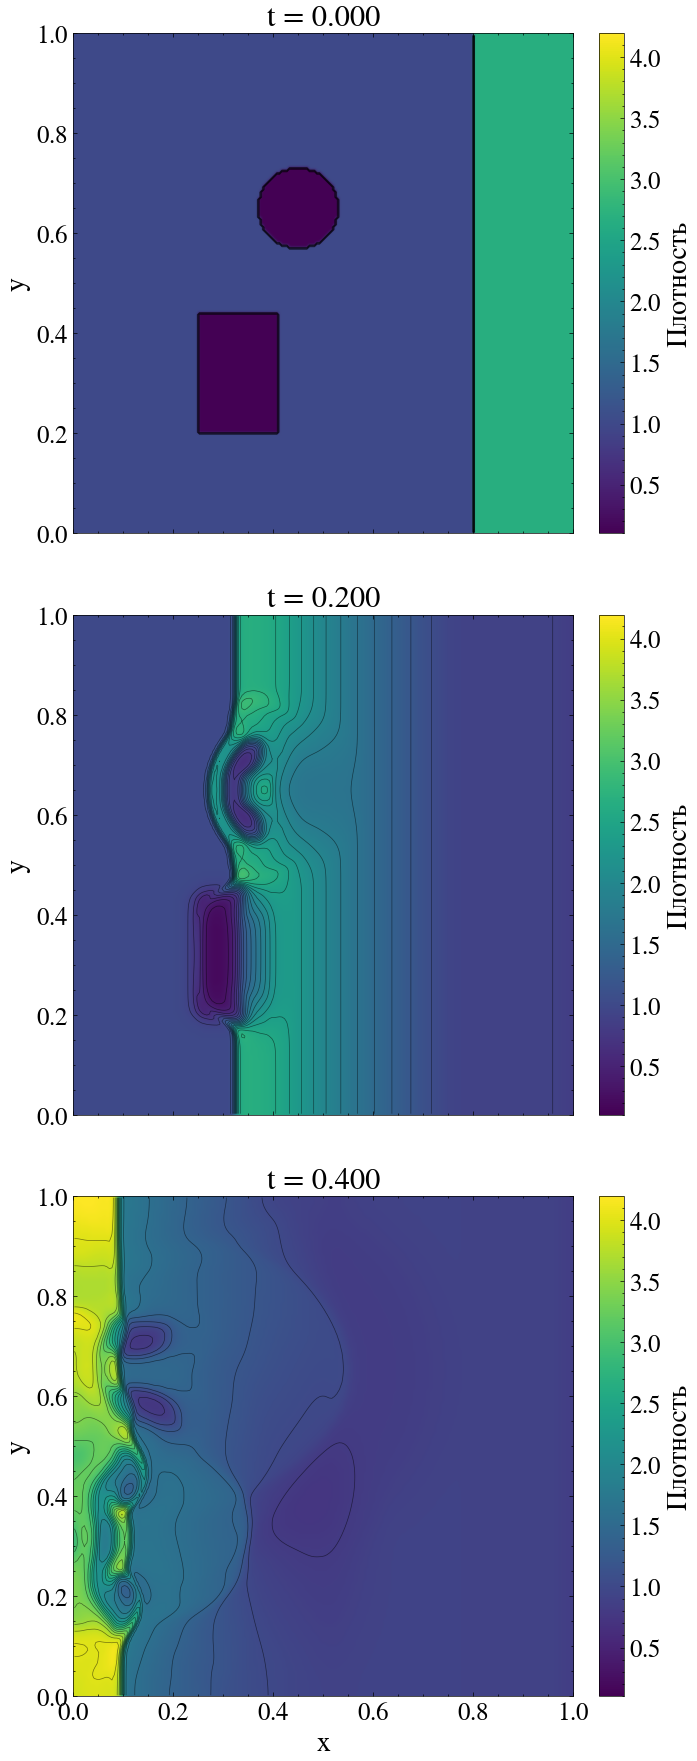

Сохранено: rho_2d_evolution.png


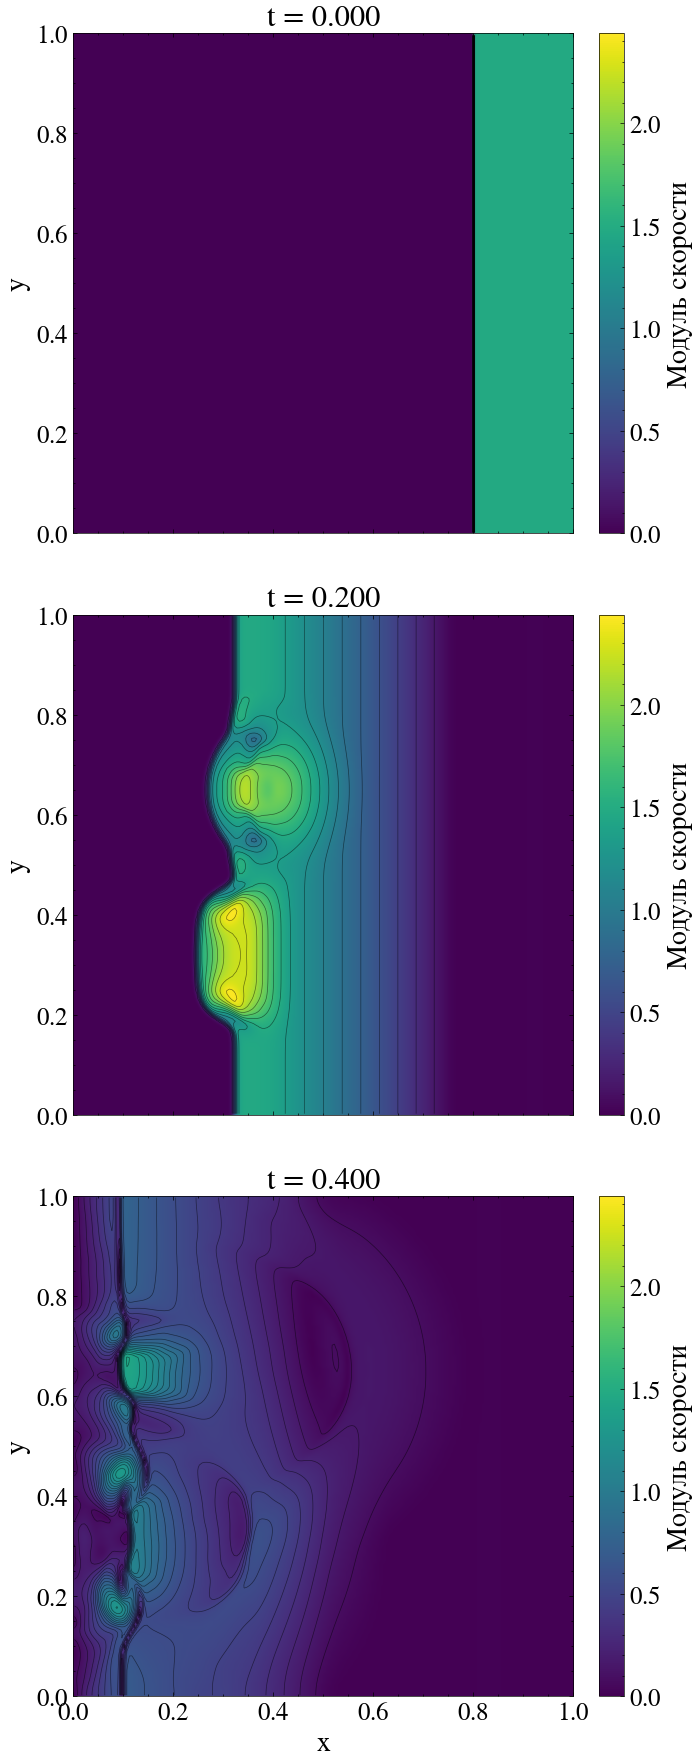

Сохранено: vel_2d_evolution.png


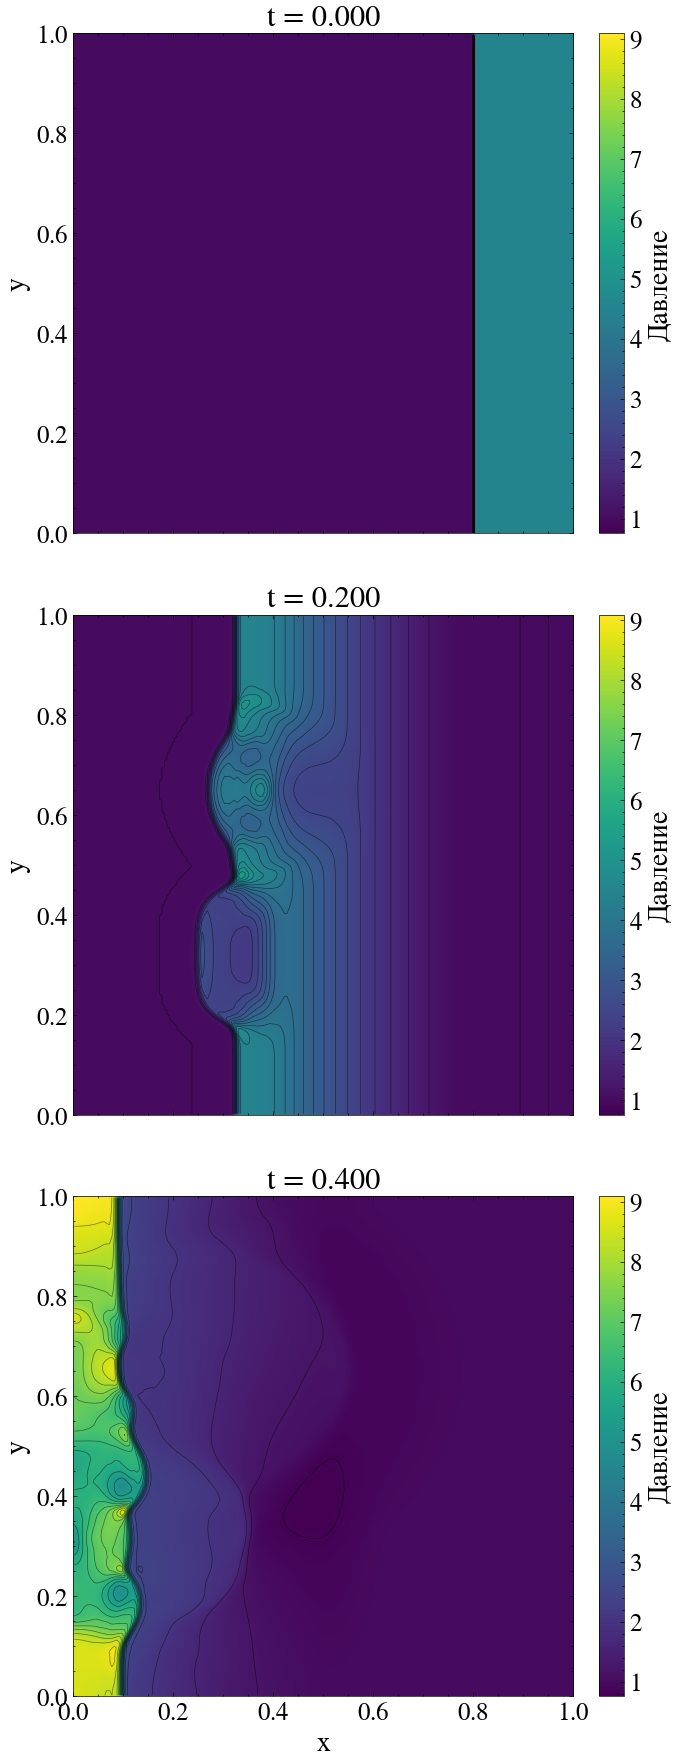

Сохранено: p_2d_evolution.png


In [ ]:
import scienceplots
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(['science', 'no-latex'])

u_data = soln['u']
X_grid = soln['X']
Y_grid = soln['Y']

# Индексы трёх моментов времени
idx_start = 0
idx_mid   = u_data.shape[0] // 2
idx_end   = u_data.shape[0] - 1
time_indices = [idx_start, idx_mid, idx_end]

# Восстанавливаем примитивные переменные
def prim_from_cons(u, gamma=1.4):
    rho  = u[..., 0]
    vel_u = u[..., 1] / rho
    vel_v = u[..., 2] / rho
    E    = u[..., 3]
    p    = (gamma - 1.0) * (E - 0.5 * rho * (vel_u**2 + vel_v**2))
    speed = np.sqrt(vel_u**2 + vel_v**2)
    return rho, speed, p

# Настройки переменных
variables = [
    {'extractor': lambda u: prim_from_cons(u)[0], 'label': 'Плотность',       'cmap': 'viridis', 'fname': 'rho_2d_evolution.png'},
    {'extractor': lambda u: prim_from_cons(u)[1], 'label': 'Модуль скорости', 'cmap': 'viridis',  'fname': 'vel_2d_evolution.png'},
    {'extractor': lambda u: prim_from_cons(u)[2], 'label': 'Давление',        'cmap': 'viridis', 'fname': 'p_2d_evolution.png'},
]

for var in variables:
    # Считаем глобальные min/max по всем трём моментам для единой цветовой шкалы
    frames_data = [var['extractor'](u_data[idx]) for idx in time_indices]
    vmin = min(d.min() for d in frames_data)
    vmax = max(d.max() for d in frames_data)

    fig, axes = plt.subplots(3, 1, figsize=(8, 18))
    fig.tight_layout(pad=4.0)

    times = [soln['t'][idx] if 't' in soln else idx for idx in time_indices]

    for row, (data, t_val) in enumerate(zip(frames_data, times)):
        ax = axes[row]

        im = ax.imshow(
            data.T,
            extent=[pars.x_init, pars.x_final, pars.y_init, pars.y_final],
            origin='lower',
            cmap=var['cmap'],
            interpolation='bicubic',
            aspect='equal',
            vmin=vmin,
            vmax=vmax,
        )

        ax.contour(
            X_grid, Y_grid, data,
            levels=20,
            colors='black',
            alpha=0.5,
            linewidths=0.5,
        )

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=18)
        cbar.set_label(var['label'], fontsize=20)

        t_label = f"t = {t_val:.3f}" if not isinstance(t_val, int) else f"кадр {t_val}"
        ax.set_title(t_label, fontsize=22)
        ax.set_ylabel('y', fontsize=20)
        ax.tick_params(axis='both', labelsize=18)

        if row < 2:
            ax.set_xticklabels([])

    axes[2].set_xlabel('x', fontsize=20)

    fig.savefig(var['fname'], dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"Сохранено: {var['fname']}")

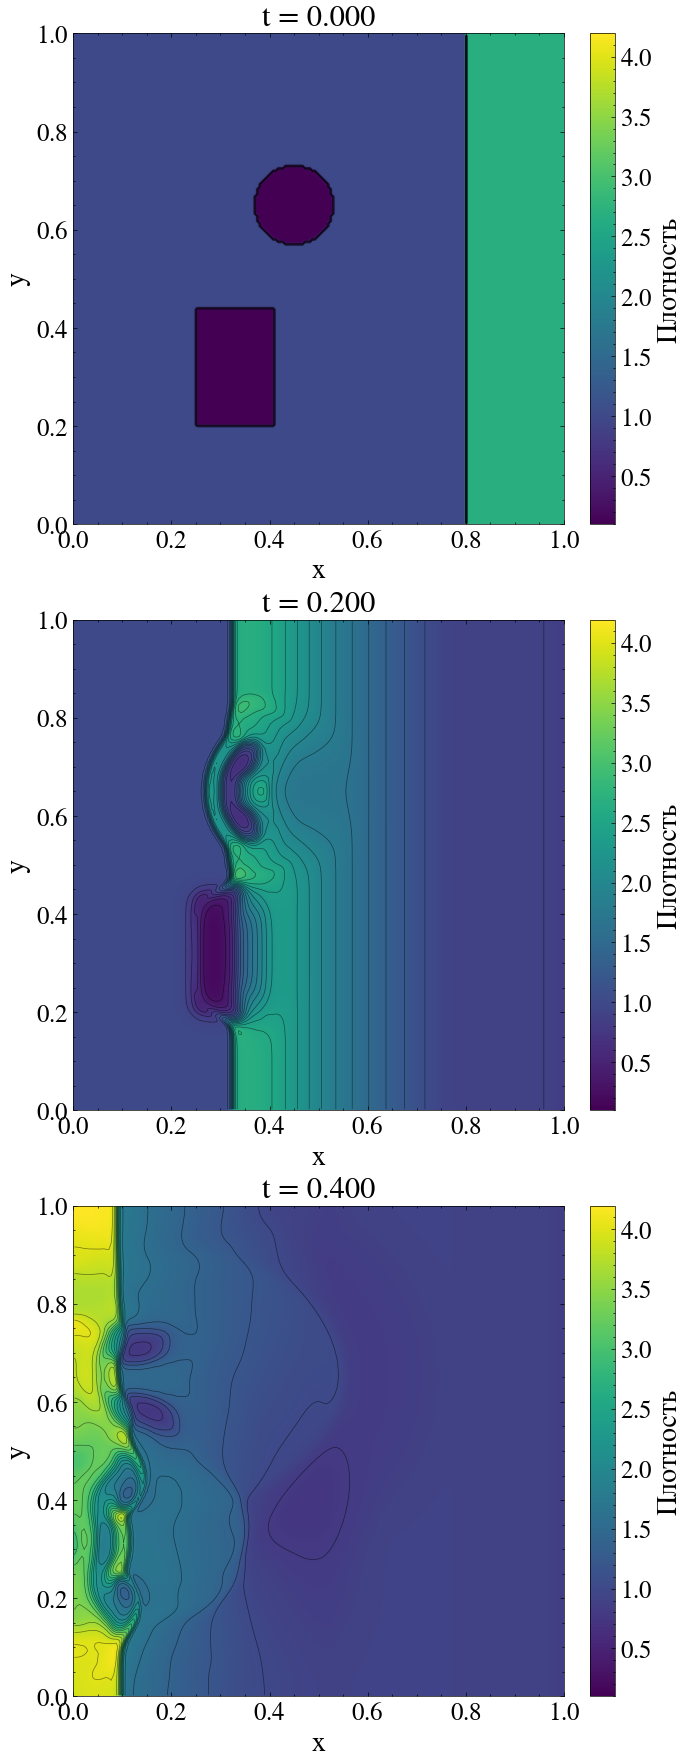

Сохранено: rho_2d_evolution.png


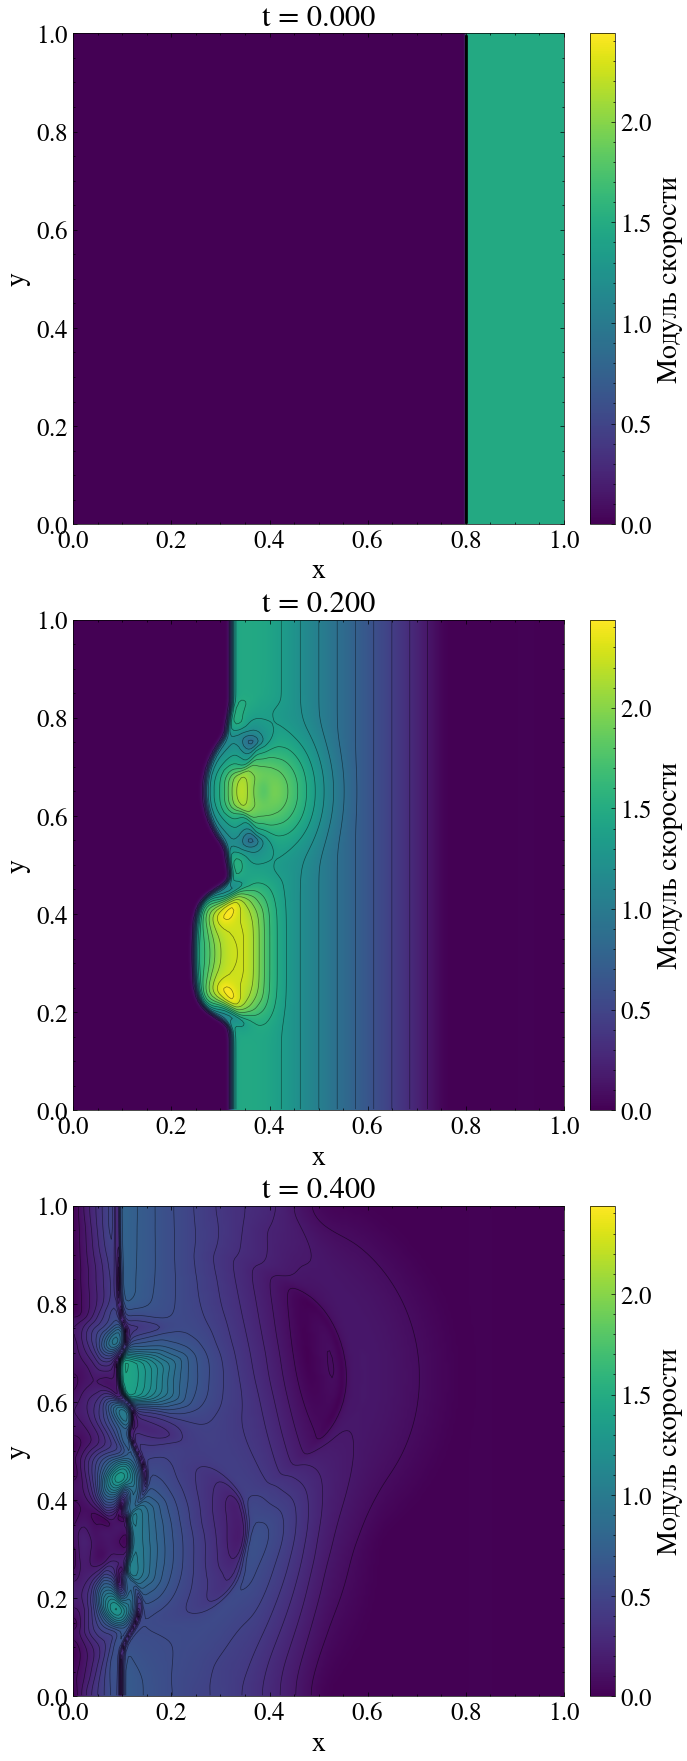

Сохранено: vel_2d_evolution.png


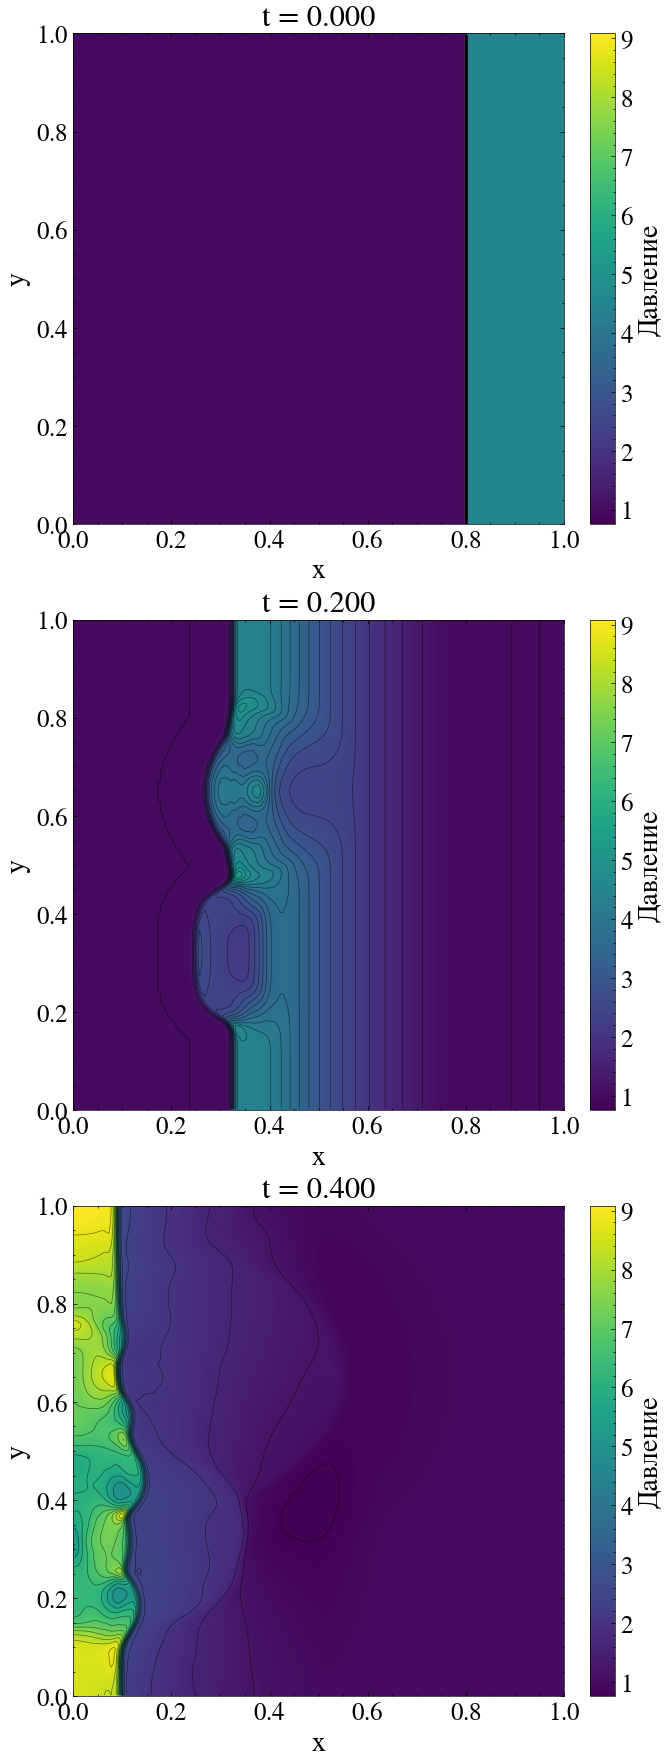

Сохранено: p_2d_evolution.png


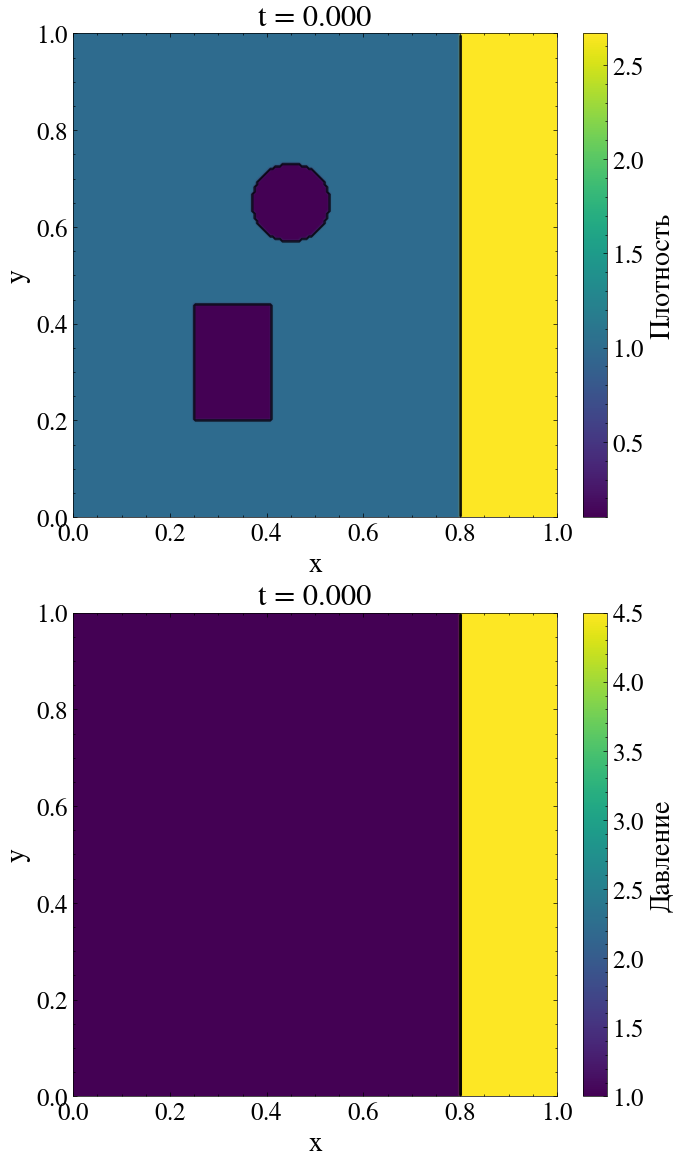

Сохранено: initial_conditions_2d.png


In [14]:
import scienceplots
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(['science', 'no-latex'])

u_data = soln['u']
X_grid = soln['X']
Y_grid = soln['Y']

idx_start = 0
idx_mid   = u_data.shape[0] // 2
idx_end   = u_data.shape[0] - 1
time_indices = [idx_start, idx_mid, idx_end]
times = [soln['t'][idx] if 't' in soln else idx for idx in time_indices]

def prim_from_cons(u, gamma=1.4):
    rho   = u[..., 0]
    vel_u = u[..., 1] / rho
    vel_v = u[..., 2] / rho
    E     = u[..., 3]
    p     = (gamma - 1.0) * (E - 0.5 * rho * (vel_u**2 + vel_v**2))
    speed = np.sqrt(vel_u**2 + vel_v**2)
    return rho, vel_u, speed, p   # rho, ux, |v|, p

variables = [
    {'extractor': lambda u: prim_from_cons(u)[0], 'label': 'Плотность',       'cmap': 'viridis', 'fname': 'rho_2d_evolution.png'},
    {'extractor': lambda u: prim_from_cons(u)[2], 'label': 'Модуль скорости', 'cmap': 'viridis', 'fname': 'vel_2d_evolution.png'},
    {'extractor': lambda u: prim_from_cons(u)[3], 'label': 'Давление',        'cmap': 'viridis', 'fname': 'p_2d_evolution.png'},
]

# ---------------------------------------------------------------
# 1. Три эволюционных файла — ось X у каждого subplot
# ---------------------------------------------------------------
for var in variables:
    frames_data = [var['extractor'](u_data[idx]) for idx in time_indices]
    vmin = min(d.min() for d in frames_data)
    vmax = max(d.max() for d in frames_data)

    fig, axes = plt.subplots(3, 1, figsize=(8, 18))
    fig.tight_layout(pad=4.0, h_pad=5.0)

    for row, (data, t_val) in enumerate(zip(frames_data, times)):
        ax = axes[row]

        im = ax.imshow(
            data.T,
            extent=[pars.x_init, pars.x_final, pars.y_init, pars.y_final],
            origin='lower',
            cmap=var['cmap'],
            interpolation='bicubic',
            aspect='equal',
            vmin=vmin,
            vmax=vmax,
        )
        ax.contour(
            X_grid, Y_grid, data,
            levels=20,
            colors='black',
            alpha=0.5,
            linewidths=0.5,
        )
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=18)
        cbar.set_label(var['label'], fontsize=20)

        t_label = f"t = {t_val:.3f}" if not isinstance(t_val, int) else f"кадр {t_val}"
        ax.set_title(t_label, fontsize=22)
        ax.set_ylabel('y', fontsize=20)
        ax.set_xlabel('x', fontsize=20)          # ← ось X у каждого
        ax.tick_params(axis='both', labelsize=18)

    fig.savefig(var['fname'], dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"Сохранено: {var['fname']}")

# ---------------------------------------------------------------
# 2. Сводный график начальных условий:
#    строка 1 — плотность rho      (imshow)
#    строка 2 — давление p         (imshow)
#    строка 3 — проекция u_x по X  (line plot, усреднение по Y)
# ---------------------------------------------------------------
rho_init = prim_from_cons(u_data[idx_start])[0]   # (Nx, Ny)
ux_init  = prim_from_cons(u_data[idx_start])[1]   # (Nx, Ny)
p_init   = prim_from_cons(u_data[idx_start])[3]   # (Nx, Ny)
t0_val   = times[0]

# x-координаты центров ячеек
x_centers = 0.5 * (X_grid[:-1, 0] + X_grid[1:, 0]) if X_grid.shape[0] > rho_init.shape[0] \
            else X_grid[:, 0]
# Если X_grid совпадает с узлами — берём средние значения по Y
ux_profile = ux_init.mean(axis=1)   # среднее по Y → форма (Nx,)
x_plot     = np.linspace(pars.x_init, pars.x_final, ux_profile.shape[0])

fig4, axes4 = plt.subplots(2, 1, figsize=(8, 12))
fig4.tight_layout(pad=4.0, h_pad=5.0)

# --- строка 1: плотность ---
ax = axes4[0]
vmin_r, vmax_r = rho_init.min(), rho_init.max()
im = ax.imshow(
    rho_init.T,
    extent=[pars.x_init, pars.x_final, pars.y_init, pars.y_final],
    origin='lower', cmap='viridis',
    interpolation='bicubic', aspect='equal',
    vmin=vmin_r, vmax=vmax_r,
)
ax.contour(X_grid, Y_grid, rho_init, levels=20,
           colors='black', alpha=0.5, linewidths=0.5)
cbar = fig4.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=18)
cbar.set_label('Плотность', fontsize=20)
ax.set_title(f"t = {t0_val:.3f}", fontsize=22)
ax.set_ylabel('y', fontsize=20)
ax.set_xlabel('x', fontsize=20)
ax.tick_params(axis='both', labelsize=18)

# --- строка 2: давление ---
ax = axes4[1]
vmin_p, vmax_p = p_init.min(), p_init.max()
im = ax.imshow(
    p_init.T,
    extent=[pars.x_init, pars.x_final, pars.y_init, pars.y_final],
    origin='lower', cmap='viridis',
    interpolation='bicubic', aspect='equal',
    vmin=vmin_p, vmax=vmax_p,
)
ax.contour(X_grid, Y_grid, p_init, levels=20,
           colors='black', alpha=0.5, linewidths=0.5)
cbar = fig4.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=18)
cbar.set_label('Давление', fontsize=20)
ax.set_title(f"t = {t0_val:.3f}", fontsize=22)
ax.set_ylabel('y', fontsize=20)
ax.set_xlabel('x', fontsize=20)
ax.tick_params(axis='both', labelsize=18)

# --- строка 3: профиль u_x вдоль X (среднее по Y) ---
# ax = axes4[2]
# ax.plot(x_plot, ux_profile, color='steelblue', linewidth=2.0)
# ax.axhline(0.0, color='gray', linewidth=0.8, linestyle='--')
# ax.set_xlim(pars.x_init, pars.x_final)
# ax.set_title(f"Профиль $u_x(x)$, среднее по $y$,  t = {t0_val:.3f}", fontsize=22)
# ax.set_xlabel('x', fontsize=20)
# ax.set_ylabel(r'$u_x$', fontsize=20)
# ax.tick_params(axis='both', labelsize=18)

fig4.savefig('initial_conditions_2d.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig4)
print("Сохранено: initial_conditions_2d.png")

In [ ]:
# Уравнение для проверки 2 порядка точности

def make_euler_isentropic_vortex_2d_colab(gamma: float = 1.4):
    """
    Гладкое точное решение: Изоэнтропийный вихрь.
    Идеально для проверки сходимости 2D Эйлера. Периодические граничные условия.
    Домен: x, y в [0, 10]. Центр вихря (5, 5). Скорость потока (1, 1).
    """

    def _compute_pressure(q):
        rho, u, v, E = q[..., 0], q[..., 1] / q[..., 0], q[..., 2] / q[..., 0], q[..., 3]
        return (gamma - 1.0) * (E - 0.5 * rho * (u ** 2 + v ** 2))

    def flux_x(q):
        rho, rhou, rhov, E = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
        u = rhou / rho;
        p = _compute_pressure(q)
        return jnp.stack([rhou, rhou * u + p, rhou * (rhov / rho), u * (E + p)], axis=-1)

    def flux_y(q):
        rho, rhou, rhov, E = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
        v = rhov / rho;
        p = _compute_pressure(q)
        return jnp.stack([rhov, rhov * (rhou / rho), rhov * v + p, v * (E + p)], axis=-1)

    def spectral_radius_x(q):
        rho, u, p = q[..., 0], q[..., 1] / q[..., 0], _compute_pressure(q)
        return jnp.abs(u) + jnp.sqrt(gamma * p / rho)

    def spectral_radius_y(q):
        rho, v, p = q[..., 0], q[..., 2] / q[..., 0], _compute_pressure(q)
        return jnp.abs(v) + jnp.sqrt(gamma * p / rho)

    # Функция генерирует точное решение для любого момента t
    def exact_solution(x, y, t=0.0):
        beta = 5.0
        # Смещение вихря с учетом скорости потока u=1, v=1 и периодичности
        dx = (x - 5.0 - t) % 10.0
        dy = (y - 5.0 - t) % 10.0
        dx = jnp.where(dx > 5.0, dx - 10.0, dx)
        dy = jnp.where(dy > 5.0, dy - 10.0, dy)

        r2 = dx ** 2 + dy ** 2
        du = - (beta / (2 * jnp.pi)) * jnp.exp(0.5 * (1.0 - r2)) * dy
        dv = (beta / (2 * jnp.pi)) * jnp.exp(0.5 * (1.0 - r2)) * dx

        u, v = 1.0 + du, 1.0 + dv
        T = 1.0 - ((gamma - 1.0) * beta ** 2 / (8 * gamma * jnp.pi ** 2)) * jnp.exp(1.0 - r2)
        rho = T ** (1.0 / (gamma - 1.0))
        p = rho ** gamma
        E = p / (gamma - 1.0) + 0.5 * rho * (u ** 2 + v ** 2)
        return jnp.stack([rho, rho * u, rho * v, E], axis=-1)

    return Equation2d(
        flux_x=flux_x, flux_y=flux_y,
        spectral_radius_x=spectral_radius_x, spectral_radius_y=spectral_radius_y,
        initial_data=lambda x, y: exact_solution(x, y, 0.0),
        boundary_handler=periodic_bc_2d,
        name="Euler 2D (Isentropic Vortex)"
    )

In [ ]:
# Проверки порядка аппроксимация экстраполяцией Ричардсона
# Использовал уравнение без ударной волны чтобы проверить что порядок будет 2
# Для уравнений с ударной волной порядок 2 не получить из за прямого следствия теоремы Годунова

def run_richardson_extrapolation(J1: int, J2: int, J3: int, equation: Equation2d, limiter: str, scheme: str):

  # Параметры для make_euler_isentropic_vortex_2d_colab() и limiter: "mc"
  # pars1 = Pars2d(
  #       x_init=0.0, x_final=10.0, y_init=0.0, y_final=10.0,
  #       t_final=5.0, dt_out=0.005, Jx=J1, Jy=J1, cfl=0.475, scheme=scheme
  #   )

  # pars2 = Pars2d(
  #         x_init=0.0, x_final=10.0, y_init=0.0, y_final=10.0,
  #         t_final=5.0, dt_out=0.005, Jx=J2, Jy=J2, cfl=0.475, scheme=scheme
  #     )

  # pars3 = Pars2d(
  #         x_init=0.0, x_final=10.0, y_init=0.0, y_final=10.0,
  #         t_final=5.0, dt_out=0.005, Jx=J3, Jy=J3, cfl=0.475, scheme=scheme
  #     )

  # Параметры для make_euler_riemann_2d() и limiter: "mc"
  pars1 = Pars2d(
        x_init=0.0, x_final=1.0, y_init=0.0, y_final=1.0,
        t_final=0.4, dt_out=0.005, Jx=J1, Jy=J1, cfl=0.475, scheme="sd2"
    )

  pars2 = Pars2d(
        x_init=0.0, x_final=1.0, y_init=0.0, y_final=1.0,
        t_final=0.4, dt_out=0.005, Jx=J2, Jy=J2, cfl=0.475, scheme="sd2"
    )

  pars3 = Pars2d(
        x_init=0.0, x_final=1.0, y_init=0.0, y_final=1.0,
        t_final=0.4, dt_out=0.005, Jx=J3, Jy=J3, cfl=0.475, scheme="sd2"
    )

  eqn = equation
  solver1 = FastSolver2d(pars1, eqn, limiter_name=limiter, scheme_name=scheme)
  u_c = solver1.solve()

  solver2 = FastSolver2d(pars2, eqn, limiter_name=limiter, scheme_name=scheme)
  u_m = solver2.solve()

  solver3 = FastSolver2d(pars3, eqn, limiter_name=limiter, scheme_name=scheme)
  u_f = solver3.solve()


  euler_vars = ["Density (rho)", "Momentum X (rho*u)", "Momentum Y (rho*v)", "Energy (E)"]

  results = self_convergence_analysis(
      u_coarse=u_c["u"][-1],
      u_medium=u_m["u"][-1],
      u_fine=u_f["u"][-1],
      r=2.0,
      var_names=euler_vars
  )

if __name__ == "__main__":
    jax.config.update("jax_enable_x64", True)
    #run_richardson_extrapolation(100, 200, 400, make_euler_isentropic_vortex_2d_colab(), "minmod", "fd2")
    run_richardson_extrapolation(100, 200, 400, make_euler_shock_stratified_2d(), "minmod", "sd2")


--------------------------------------------------
Анализ самосходимости (Экстраполяция Ричардсона)
Коэффициент измельчения (r) = 1.0
--------------------------------------------------

--- Density (rho) ---
Норма L1:
  Ошибка (Крупная-Средняя): 2.7349e-02
  Ошибка (Средняя-Мелкая):  1.9142e-02
  Наблюдаемый порядок (p):  inf
Норма L2:
  Ошибка (Крупная-Средняя): 6.6126e-02
  Ошибка (Средняя-Мелкая):  5.8111e-02
  Наблюдаемый порядок (p):  inf
Норма Linf:
  Ошибка (Крупная-Средняя): 8.8338e-01
  Ошибка (Средняя-Мелкая):  1.0887e+00
  Наблюдаемый порядок (p):  -inf

--- Momentum X (rho*u) ---
Норма L1:
  Ошибка (Крупная-Средняя): 3.3074e-02
  Ошибка (Средняя-Мелкая):  2.1225e-02
  Наблюдаемый порядок (p):  inf
Норма L2:
  Ошибка (Крупная-Средняя): 9.9751e-02
  Ошибка (Средняя-Мелкая):  7.0449e-02
  Наблюдаемый порядок (p):  inf
Норма Linf:
  Ошибка (Крупная-Средняя): 1.3840e+00
  Ошибка (Средняя-Мелкая):  1.6964e+00
  Наблюдаемый порядок (p):  -inf

--- Momentum Y (rho*v) ---
Норма L1:


/content/diploma_centpy_parallelization_py/jax_centpy/richardson.py:74: RuntimeWarning: divide by zero encountered in divide
  p = np.log(error_mc_safe / error_fm_safe) / np.log(r)


In [ ]:
def run_richardson_extrapolation(J1: int, J2: int, J3: int, equation: Equation2d, limiter: str):

  # Параметры для make_euler_isentropic_vortex_2d_colab() и limiter: "mc"
  pars1 = Pars2d(
        x_init=0.0, x_final=10.0, y_init=0.0, y_final=10.0,
        t_final=5.0, dt_out=0.005, Jx=J1, Jy=J1, cfl=0.475, scheme="sd2"
    )

  pars2 = Pars2d(
          x_init=0.0, x_final=10.0, y_init=0.0, y_final=10.0,
          t_final=5.0, dt_out=0.005, Jx=J2, Jy=J2, cfl=0.475, scheme="sd2"
      )

  pars3 = Pars2d(
          x_init=0.0, x_final=10.0, y_init=0.0, y_final=10.0,
          t_final=5.0, dt_out=0.005, Jx=J3, Jy=J3, cfl=0.475, scheme="sd2"
      )

  eqn = equation
  solver1 = FastSolverWithAllLayersWithoutExtends2d(pars1, eqn, limiter_name=limiter)
  u_c = solver1.solve()

  solver2 = FastSolverWithAllLayersWithoutExtends2d(pars2, eqn, limiter_name=limiter)
  u_m = solver2.solve()

  solver3 = FastSolverWithAllLayersWithoutExtends2d(pars3, eqn, limiter_name=limiter)
  u_f = solver3.solve()


  euler_vars = ["Density (rho)", "Momentum X (rho*u)", "Momentum Y (rho*v)", "Energy (E)"]

  results = self_convergence_analysis(
      u_coarse=u_c["u"][-1],
      u_medium=u_m["u"][-1],
      u_fine=u_f["u"][-1],
      r=2.0,
      var_names=euler_vars
  )

if __name__ == "__main__":
    jax.config.update("jax_enable_x64", True)
    run_richardson_extrapolation(50, 100, 200, make_euler_isentropic_vortex_2d_colab(), "minmod")


--------------------------------------------------
Анализ самосходимости (Экстраполяция Ричардсона)
Коэффициент измельчения (r) = 2.0
--------------------------------------------------

--- Density (rho) ---
Норма L1:
  Ошибка (Крупная-Средняя): 8.4059e-03
  Ошибка (Средняя-Мелкая):  2.7393e-03
  Наблюдаемый порядок (p):  1.6176
Норма L2:
  Ошибка (Крупная-Средняя): 1.9400e-02
  Ошибка (Средняя-Мелкая):  5.9431e-03
  Наблюдаемый порядок (p):  1.7067
Норма Linf:
  Ошибка (Крупная-Средняя): 1.5167e-01
  Ошибка (Средняя-Мелкая):  5.5633e-02
  Наблюдаемый порядок (p):  1.4469

--- Momentum X (rho*u) ---
Норма L1:
  Ошибка (Крупная-Средняя): 1.6188e-02
  Ошибка (Средняя-Мелкая):  5.2003e-03
  Наблюдаемый порядок (p):  1.6383
Норма L2:
  Ошибка (Крупная-Средняя): 3.4163e-02
  Ошибка (Средняя-Мелкая):  1.0916e-02
  Наблюдаемый порядок (p):  1.6459
Норма Linf:
  Ошибка (Крупная-Средняя): 2.2182e-01
  Ошибка (Средняя-Мелкая):  7.2168e-02
  Наблюдаемый порядок (p):  1.6200

--- Momentum Y (rho*v

In [ ]:
def run_with_different_mesh(grids: list[int], equation, limiter: str):
    """
    Запускает решатель последовательно на массиве различных сеток.

    :param grids: Список размеров сеток (например, [50, 100, 200])
    :param equation: Объект уравнения
    :param limiter: Название лимитера
    :return: Словарь с результатами и временем выполнения для каждой сетки
    """
    all_results = {}

    for J in grids:
        print(f"\n{'='*50}")
        print(f"Инициализация сетки: {J}x{J}")
        print(f"{'='*50}")

        # 1. Создаем параметры для текущей сетки
        pars = Pars2d(
            x_init=0.0, x_final=1.0,
            y_init=0.0, y_final=1.0,
            t_final=0.4, dt_out=0.005,
            Jx=J, Jy=J, cfl=0.475, scheme="sd2"
        )

        # 2. Инициализируем решатель
        solver = FastSolver2d(pars, equation, limiter_name=limiter)

        # 3. Прогрев JAX под новые размеры массивов (shape)
        print(f"--- Прогрев JAX (Компиляция XLA) для {J}x{J} ---")
        x_1d = jnp.linspace(pars.x_init + pars.dx / 2, pars.x_final - pars.dx / 2, pars.Jx)
        y_1d = jnp.linspace(pars.y_init + pars.dy / 2, pars.y_final - pars.dy / 2, pars.Jy)
        X, Y = jnp.meshgrid(x_1d, y_1d, indexing='ij')

        test_u = equation.initial_data(X, Y)

        # Прогреваем только один шаг, чтобы JAX скомпилировал XLA-граф
        _ = solver.update_step_jit(0.0, test_u, 0.001).block_until_ready()
        print("Прогрев завершен.\n")

        # 4. Основной запуск и бенчмарк
        print(f"--- Запуск JAX GPU Бенчмарка ---")
        t0 = time.time()

        results = solver.solve()
        results['u'][-1].block_until_ready() # Ждем завершения вычислений на GPU

        t1 = time.time()
        elapsed_time = t1 - t0

        print(f"[GPU JAX] Чистое время выполнения для {J}x{J}: {elapsed_time:.4f} секунд")

        # 5. Сохраняем результаты
        all_results[J] = {
            'time': elapsed_time,
            'u_final': results['u'][-1],
            'results_full': results
        }

    return all_results

if __name__ == "__main__":
    # Включаем двойную точность (обязательно для численных методов и экстраполяции)
    jax.config.update("jax_enable_x64", True)

    # Задаем массив сеток, по которым хотим пройтись
    grid_sizes = [40, 80, 160, 200, 320]

    # Создаем уравнение
    eqn = make_euler_riemann_2d()

    # Запускаем наш цикл
    run_results = run_with_different_mesh(grid_sizes, eqn, "minmod")

    # Если дальше вам нужно использовать эти данные для Ричардсона,
    # вы можете достать их из словаря:
    # u_c = run_results[50]['u_final']
    # u_m = run_results[100]['u_final']
    # u_f = run_results[200]['u_final']


Инициализация сетки: 40x40
--- Прогрев JAX (Компиляция XLA) для 40x40 ---
Прогрев завершен.

--- Запуск JAX GPU Бенчмарка ---
Starting 2D simulation: Euler 2D Riemann
Grid: 40x40, Scheme: SD2/minmod
[GPU JAX] Чистое время выполнения для 40x40: 0.2829 секунд

Инициализация сетки: 80x80
--- Прогрев JAX (Компиляция XLA) для 80x80 ---
Прогрев завершен.

--- Запуск JAX GPU Бенчмарка ---
Starting 2D simulation: Euler 2D Riemann
Grid: 80x80, Scheme: SD2/minmod
[GPU JAX] Чистое время выполнения для 80x80: 0.4103 секунд

Инициализация сетки: 160x160
--- Прогрев JAX (Компиляция XLA) для 160x160 ---
Прогрев завершен.

--- Запуск JAX GPU Бенчмарка ---
Starting 2D simulation: Euler 2D Riemann
Grid: 160x160, Scheme: SD2/minmod
[GPU JAX] Чистое время выполнения для 160x160: 0.8466 секунд

Инициализация сетки: 200x200
--- Прогрев JAX (Компиляция XLA) для 200x200 ---
Прогрев завершен.

--- Запуск JAX GPU Бенчмарка ---
Starting 2D simulation: Euler 2D Riemann
Grid: 200x200, Scheme: SD2/minmod
[GPU JAX]

In [ ]:
from exect_solve_too_task_for_1d_2d import verify_sine_1d, verify_vortex_2d

verify_vortex_2d(make_euler_isentropic_vortex_2d_colab(), scheme_name="fd2", limiter="average", t_final=1.0, grids=[50, 100, 200, 400])

ВЕРИФИКАЦИЯ 2D: ИЗОЭНТРОПИЙНЫЙ ВИХРЬ (схема: fd2)
  N=  50×50   готово
  N= 100×100  готово
  N= 200×200  готово
  N= 400×400  готово

  rho:
         N |          L1   p_L1 |          L2   p_L2
  ------------------------------------------------
        50 |  1.5000e-03 --- |  3.3892e-03 ---
       100 |  1.7397e-04   3.11 |  4.1438e-04   3.03
       200 |  3.0889e-05   2.49 |  7.3296e-05   2.50
       400 |  6.3653e-06   2.28 |  1.5029e-05   2.29

  u:
         N |          L1   p_L1 |          L2   p_L2
  ------------------------------------------------
        50 |  3.9326e-03 --- |  9.4595e-03 ---
       100 |  4.0580e-04   3.28 |  1.0499e-03   3.17
       200 |  7.5652e-05   2.42 |  1.8987e-04   2.47
       400 |  1.6323e-05   2.21 |  3.9589e-05   2.26

  v:
         N |          L1   p_L1 |          L2   p_L2
  ------------------------------------------------
        50 |  3.9287e-03 --- |  9.3703e-03 ---
       100 |  3.9193e-04   3.33 |  9.8126e-04   3.26
       200 |  6.9098e-

[(50,
  [(np.float64(0.0014999923907002045), np.float64(0.003389193233244711)),
   (np.float64(0.003932616366597787), np.float64(0.009459490312990263)),
   (np.float64(0.00392869312473295), np.float64(0.00937027627869607)),
   (np.float64(0.0018366131299707583), np.float64(0.005167669775267611))]),
 (100,
  [(np.float64(0.00017397015510686934), np.float64(0.000414383398933728)),
   (np.float64(0.00040580121058585893), np.float64(0.001049851012469361)),
   (np.float64(0.00039193345343565514), np.float64(0.0009812647213803662)),
   (np.float64(0.000199330860561608), np.float64(0.0005185830359252262))]),
 (200,
  [(np.float64(3.0889284549587616e-05), np.float64(7.329640221587624e-05)),
   (np.float64(7.565156769022972e-05), np.float64(0.00018987411255606246)),
   (np.float64(6.909820313498756e-05), np.float64(0.00016480725629688605)),
   (np.float64(3.624628268617965e-05), np.float64(9.010197047718234e-05))]),
 (400,
  [(np.float64(6.365315198063121e-06), np.float64(1.502900635113731e-05)


ГРАФИК ЭВОЛЮЦИИ TV(t) для 2D


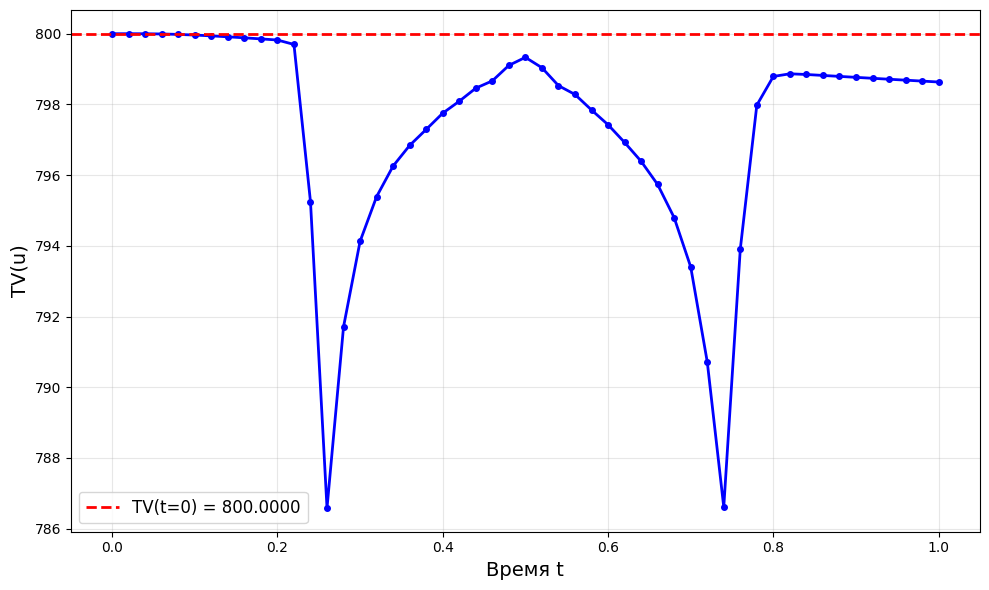


TVD-ДИАГНОСТИКА (2D)
TV начальная:              800.000000
TV финальная:              798.633900
Абсолютное изменение:      -1.366100e+00
Относительное изменение:   -1.7076e-03 (-0.17%)
Макс локальный скачок:     7.2984e+00
Количество нарушений:      0
------------------------------------------------------------
ВЕРДИКТ: ✓ Отлично: TV почти постоянна
TVD выполняется: ✓ ДА


In [ ]:
from tvd_analysis import (
    plot_tv_evolution_only_2d,  # ДЛЯ 2D!
    compute_tv_evolution_2d,
    check_tvd_property
)

# Инициализация 2D задачи (например, вихрь)
def make_linear_advection_2d(vx: float = 1.0, vy: float = 1.0, radius: float = 0.25):
    """
    Двумерное уравнение линейной адвекции:
        u_t + vx * u_x + vy * u_y = 0

    Начальные условия: круговая «шапка» на периодической области [0,1]^2:
        u(x, y, 0) = 1  если  sqrt((x-0.5)^2 + (y-0.5)^2) < radius
                     0  иначе

    Формат состояния:
        u : ndarray (Jx, Jy, 1)
    """

    def flux_x(q):
        return vx * q

    def flux_y(q):
        return vy * q

    def spectral_radius_x(q):
        return jnp.full(q.shape[:-1], jnp.abs(vx))

    def spectral_radius_y(q):
        return jnp.full(q.shape[:-1], jnp.abs(vy))

    def initial_data(x, y):
        r = jnp.sqrt((x - 0.5) ** 2 + (y - 0.5) ** 2)
        u0 = jnp.where(r < radius, 1.0, 0.0)
        return u0[..., jnp.newaxis]

    return Equation2d(
        flux_x=flux_x,
        flux_y=flux_y,
        spectral_radius_x=spectral_radius_x,
        spectral_radius_y=spectral_radius_y,
        initial_data=initial_data,
        boundary_handler=periodic_bc_2d,
        name=f"Linear Advection 2D (vx={vx}, vy={vy}, r={radius})",
    )

eqn = make_linear_advection_2d()

pars = Pars2d(
    x_init=0.0,
    x_final=1.0,
    y_init=0.0,
    y_final=1.0,
    t_final=1.0,
    dt_out=0.02,
    Jx=400,
    Jy=400,
    cfl=0.45,
    scheme="sd2"
)

# Решение задачи
from solver import FastSolverWithAllLayersWithoutExtends2d

solver_2d = FastSolverWithAllLayersWithoutExtends2d(
    pars, eqn, limiter_name="minmod", scheme_name="sd2"
)
sol_2d = solver_2d.solve()

# ==================== ПРОСТО ПОКАЗАТЬ ГРАФИК ====================
print("\n" + "="*60)
print("ГРАФИК ЭВОЛЮЦИИ TV(t) для 2D")
print("="*60)

plot_tv_evolution_only_2d(
    sol_2d,
    variable_idx=0,
    figsize=(10, 6),
    show=True,           # Показать на экране
    save_path=None,      # НЕ сохранять в файл
    dpi=150
)

# ==================== TVD-ДИАГНОСТИКА ====================
tv_times, tv_values = compute_tv_evolution_2d(sol_2d, variable_idx=0)
is_tvd, diag = check_tvd_property(tv_values, tolerance=0.05)

print("\n" + "="*60)
print("TVD-ДИАГНОСТИКА (2D)")
print("="*60)
print(f"TV начальная:              {diag['tv_initial']:.6f}")
print(f"TV финальная:              {diag['tv_final']:.6f}")
print(f"Абсолютное изменение:      {diag['absolute_change']:.6e}")
print(f"Относительное изменение:   {diag['relative_change']:.4e} ({diag['relative_change']*100:.2f}%)")
print(f"Макс локальный скачок:     {diag['max_jump']:.4e}")
print(f"Количество нарушений:      {diag['violations_count']}")
print("-" * 60)
print(f"ВЕРДИКТ: {diag['verdict']}")
print(f"TVD выполняется: {'✓ ДА' if is_tvd else '✗ НЕТ'}")
print("="*60)

✓ Сохранено: animation/advection_2d_maxprin_sd2.png


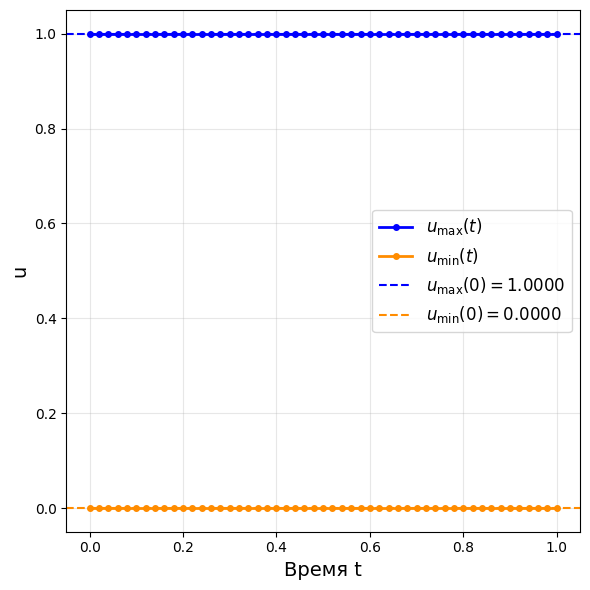

ДИАГНОСТИКА ПРИНЦИПА МАКСИМУМА (2D)
u_min начальное:    0.000000
u_max начальное:    1.000000
u_min финальное:    0.000000
u_max финальное:    1.000000
Макс. undershoot:   0.0000e+00
Макс. overshoot:    0.0000e+00
Нарушений снизу:    0
Нарушений сверху:   0
------------------------------------------------------------
ВЕРДИКТ: ✓ Отлично: принцип максимума строго выполнен
Принцип максимума: ✓ ДА


In [ ]:
from max_principle_analysis_final import (
    compute_minmax_evolution_2d,
    check_max_principle,
    plot_max_principle_evolution_2d,
    print_max_principle_diagnostics,
)

def make_linear_advection_2d(vx: float = 1.0, vy: float = 1.0, radius: float = 0.25):
    """
    Двумерное уравнение линейной адвекции:
        u_t + vx * u_x + vy * u_y = 0

    Начальные условия: круговая «шапка» на периодической области [0,1]^2:
        u(x, y, 0) = 1  если  sqrt((x-0.5)^2 + (y-0.5)^2) < radius
                     0  иначе

    Формат состояния:
        u : ndarray (Jx, Jy, 1)
    """

    def flux_x(q):
        return vx * q

    def flux_y(q):
        return vy * q

    def spectral_radius_x(q):
        return jnp.full(q.shape[:-1], jnp.abs(vx))

    def spectral_radius_y(q):
        return jnp.full(q.shape[:-1], jnp.abs(vy))

    def initial_data(x, y):
        r = jnp.sqrt((x - 0.5) ** 2 + (y - 0.5) ** 2)
        u0 = jnp.where(r < radius, 1.0, 0.0)
        return u0[..., jnp.newaxis]

    return Equation2d(
        flux_x=flux_x,
        flux_y=flux_y,
        spectral_radius_x=spectral_radius_x,
        spectral_radius_y=spectral_radius_y,
        initial_data=initial_data,
        boundary_handler=periodic_bc_2d,
        name=f"Linear Advection 2D (vx={vx}, vy={vy}, r={radius})",
    )

eqn = make_linear_advection_2d()

pars = Pars2d(
    x_init=0.0,
    x_final=1.0,
    y_init=0.0,
    y_final=1.0,
    t_final=1.0,
    dt_out=0.02,
    Jx=400,
    Jy=400,
    cfl=0.27,
    scheme="sd2"
)

from solver import FastSolverWithAllLayersWithoutExtends2d

solver_2d = FastSolverWithAllLayersWithoutExtends2d(
    pars, eqn, limiter_name="minmod", scheme_name="fd2"
)
sol_2d = solver_2d.solve()

# sol_2d — результат solver_2d.solve() вашей линейной адвекции 2D

# ========== ГРАФИК ==========
plot_max_principle_evolution_2d(
    sol_2d,
    variable_idx=0,
    figsize=(6, 6),
    show=True,
    save_path="./animation/advection_2d_maxprin_sd2.png",
    dpi=150,
)

# ========== ДИАГНОСТИКА ==========
times, u_min, u_max = compute_minmax_evolution_2d(sol_2d, variable_idx=0)
is_ok, diag = check_max_principle(times, u_min, u_max)
print_max_principle_diagnostics(diag)

In [ ]:
#!/usr/bin/env python3
"""
Генерация графиков сравнения для дипломной (гладкие решения).
"""

import jax.numpy as jnp
import numpy as np
from solver import (
    FastSolverWithAllLayersWithoutExtends1d,
    FastSolverWithAllLayersWithoutExtends2d
)
from comparison_plot import (
    plot_1d_comparison,
    plot_1d_comparison_error,
    plot_2d_comparison,
    plot_2d_comparison_profiles,
    plot_2d_side_by_side
)


# ============================================================================
# АНАЛИТИЧЕСКИЕ РЕШЕНИЯ
# ============================================================================

def exact_solution_isentropic_vortex_2d(X, Y, t, center=(5.0, 5.0),
                                         strength=5.0, velocity_inf=(1.0, 1.0),
                                         rho_inf=1.0, p_inf=1.0, gamma=1.4):
    """
    Точное решение для задачи изоэнтропийного вихря Ху-Шу.

    Вихрь переносится с постоянной скоростью velocity_inf без изменения формы.

    Args:
        X, Y: сетки координат (массивы Jx × Jy)
        t: время
        center: начальное положение центра вихря (x0, y0)
        strength: интенсивность вихря (ε)
        velocity_inf: фоновая скорость (u_inf, v_inf)
        rho_inf: фоновая плотность
        p_inf: фоновое давление
        gamma: показатель адиабаты

    Returns:
        u_exact: консервативные переменные (Jx, Jy, 4) [ρ, ρu, ρv, E]
    """
    x0, y0 = center
    u_inf, v_inf = velocity_inf
    epsilon = strength

    # Сдвиг центра вихря из-за адвекции
    x_center = x0 + u_inf * t
    y_center = y0 + v_inf * t

    # Периодическая коррекция для области [0, 10] × [0, 10]
    # (предполагается периодические граничные условия)
    domain_size = 10.0
    x_center = x_center % domain_size
    y_center = y_center % domain_size

    # Расстояние от центра вихря
    dx = X - x_center
    dy = Y - y_center

    # Учёт периодичности (ближайшее расстояние)
    dx = jnp.where(jnp.abs(dx) > domain_size / 2,
                   dx - jnp.sign(dx) * domain_size, dx)
    dy = jnp.where(jnp.abs(dy) > domain_size / 2,
                   dy - jnp.sign(dy) * domain_size, dy)

    r_squared = dx**2 + dy**2

    # Возмущения скорости и температуры
    exp_factor = jnp.exp((1.0 - r_squared) / 2.0)

    delta_u = -(epsilon / (2.0 * jnp.pi)) * dy * exp_factor
    delta_v = +(epsilon / (2.0 * jnp.pi)) * dx * exp_factor
    delta_T = -(gamma - 1.0) * epsilon**2 / (8.0 * gamma * jnp.pi**2) * \
              jnp.exp(1.0 - r_squared)

    # Примитивные переменные
    u = u_inf + delta_u
    v = v_inf + delta_v
    T = 1.0 + delta_T  # T_inf = p_inf / rho_inf = 1.0 для γ=1.4

    # Изоэнтропийные соотношения: p/ρ^γ = const
    # T = p / ρ (для идеального газа с R=1)
    # => ρ = T^(1/(γ-1)), p = T^(γ/(γ-1))
    rho = rho_inf * T**(1.0 / (gamma - 1.0))
    p = p_inf * T**(gamma / (gamma - 1.0))

    # Консервативные переменные
    rho_u = rho * u
    rho_v = rho * v
    E = p / (gamma - 1.0) + 0.5 * rho * (u**2 + v**2)

    # Упаковка в массив (Jx, Jy, 4)
    u_exact = jnp.stack([rho, rho_u, rho_v, E], axis=-1)

    return u_exact


def create_exact_solution_dict_2d(pars, eqn, center=(5.0, 5.0),
                                   strength=5.0, velocity_inf=(1.0, 1.0)):
    """
    Создаёт словарь с точным решением для 2D задачи (аналог solver.solve()).

    Returns:
        solution: {'X': ..., 'Y': ..., 't': ..., 'u': [...]}
    """
    Jx = pars['Jx']
    Jy = pars['Jy']
    T = pars['T']
    x_min, x_max = pars['x_range']
    y_min, y_max = pars['y_range']

    # Сетка
    dx = (x_max - x_min) / Jx
    dy = (y_max - y_min) / Jy

    x = jnp.linspace(x_min + dx/2, x_max - dx/2, Jx)
    y = jnp.linspace(y_min + dy/2, y_max - dy/2, Jy)
    X, Y = jnp.meshgrid(x, y, indexing='ij')

    # Временные слои
    gamma = 1.4
    u_max = jnp.sqrt(2.0) + jnp.sqrt(gamma)  # диагональная адвекция
    dt = pars['C'] * min(dx, dy) / u_max
    n_steps = int(jnp.ceil(T / dt))

    times = []
    u_snapshots = []

    # Начальный момент
    t = 0.0
    u_exact = exact_solution_isentropic_vortex_2d(
        X, Y, t, center, strength, velocity_inf
    )
    times.append(t)
    u_snapshots.append(np.array(u_exact))

    # Остальные моменты
    for n in range(1, n_steps + 1):
        t = n * dt
        if t > T:
            t = T
        u_exact = exact_solution_isentropic_vortex_2d(
            X, Y, t, center, strength, velocity_inf
        )
        times.append(t)
        u_snapshots.append(np.array(u_exact))
        if t >= T:
            break

    return {
        'X': np.array(X),
        'Y': np.array(Y),
        't': times,
        'u': u_snapshots
    }


# ============================================================================
# ОСНОВНОЙ СКРИПТ
# ============================================================================

if __name__ == "__main__":


    # ==================== 2D: Вихрь Ху-Шу ====================
    print("\n" + "="*60)
    print("2D: ВИХРЬ ХУ-ШУ")
    print("="*60)

    # Параметры
    pars = Pars2d(
            x_init=0.0,
            x_final=10.0,
            y_init=0.0,
            y_final=10.0,
            t_final=1.0,
            dt_out=0.005,
            Jx=80,
            Jy=80,
            cfl=0.475,
            scheme="sd2"
        )

    pars_2d = {
        'Jx': 80,
        'Jy': 80,
        'T': 10.0,
        'C': 0.475,
        'x_range': (0.0, 10.0),
        'y_range': (0.0, 10.0),
        'boundary': 'periodic'
    }

    # Уравнение
    center = (5.0, 5.0)
    strength = 5.0
    velocity_inf = (1.0, 1.0)

    eqn_2d = make_euler_isentropic_vortex_2d_colab()

    # Численное решение
    print("Запуск численного решения 2D...")
    solver_num_2d = FastSolverWithAllLayersWithoutExtends2d(
        pars, eqn_2d, limiter_name="minmod", scheme_name = "fd2"
    )
    sol_num_2d = solver_num_2d.solve()
    print(f"✓ Численное решение: {len(sol_num_2d['t'])} временных слоёв")

    # Точное решение (аналитическое)
    print("Генерация точного решения 2D...")
    sol_exact_2d = create_exact_solution_dict_2d(
        pars_2d, eqn_2d, center=center, strength=strength,
        velocity_inf=velocity_inf
    )
    print(f"✓ Точное решение: {len(sol_exact_2d['t'])} временных слоёв")

    # Графики
    print("\n--- Создание графиков 2D ---")

    plot_2d_comparison(
        sol_num_2d, sol_exact_2d,
        variable_idx=0,
        variable_name="Плотность ρ",
        output_path="diploma_figures/vortex_comparison_2d.png",
        dpi=300,
        cmap='jet'
    )

    plot_2d_comparison_profiles(
        sol_num_2d, sol_exact_2d,
        variable_idx=0,
        variable_name="Плотность ρ",
        slice_x=5.0,
        slice_y=5.0,
        output_path="diploma_figures/vortex_profiles_2d.png",
        dpi=300
    )

    # Отдельные файлы для subfigure
    plot_2d_side_by_side(
        sol_num_2d, sol_exact_2d,
        variable_idx=0,
        variable_name="Плотность ρ",
        output_dir="diploma_figures",
        prefix="vortex",
        dpi=300
    )

    print("\n" + "="*60)
    print("ГОТОВО! Все графики сохранены в diploma_figures/")
    print("="*60)


2D: ВИХРЬ ХУ-ШУ
Запуск численного решения 2D...
✓ Численное решение: 201 временных слоёв
Генерация точного решения 2D...
✓ Точное решение: 439 временных слоёв

--- Создание графиков 2D ---
✓ Сохранено: diploma_figures/vortex_comparison_2d.png
✓ Сохранено: diploma_figures/vortex_profiles_2d.png
✓ Сохранено: diploma_figures/vortex_numerical_2d.png
✓ Сохранено: diploma_figures/vortex_exact_2d.png

ГОТОВО! Все графики сохранены в diploma_figures/
